# Exploratory Data Analysis
## Loads the Twibot-22 dataset and explores distributions, class balance, and initial patterns.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os

df = pd.read_csv("../data/raw/twibot-22.csv.gz", compression="gzip")
df.head()

,id,label
0,u1217628182611927040,human
1,u2664730894,human
2,u1266703520205549568,human
3,u1089159225148882949,human
4,u36741729,bot


## File Inspection

In [16]:
DATA_DIR = "../data/raw"

# Load each file — adjust filenames when the full dataset arrives
labels = pd.read_csv(f"{DATA_DIR}/twibot-22.csv.gz", compression="gzip")

# Twibot-22 typically ships these — uncomment as files arrive:
# users  = pd.read_json(f"{DATA_DIR}/user.json")
# tweets = pd.read_json(f"{DATA_DIR}/tweet.json")
# edges  = pd.read_csv(f"{DATA_DIR}/edge.csv")
# splits = pd.read_csv(f"{DATA_DIR}/split.csv")

# Inspect each loaded file
for name, df in [("labels", labels)]:  # add others as they arrive
    print(f"{'='*40}")
    print(f"FILE: {name}")
    print(f"Shape: {df.shape}")
    print(f"\nColumns & dtypes:")
    print(df.dtypes)
    print(f"\nFirst 3 rows:")
    display(df.head(3))

FILE: labels
Shape: (1000000, 2)

Columns & dtypes:
id       str
label    str
dtype: object

First 3 rows:


,id,label
0,u1217628182611927040,human
1,u2664730894,human
2,u1266703520205549568,human


## Missing Data

In [17]:
def missing_audit(df, name):
    total = len(df)
    missing = df.isnull().sum()
    pct = (missing / total * 100).round(2)
    audit = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": pct
    }).sort_values("missing_pct", ascending=False)
    
    print(f"\n--- Missing Data: {name} ---")
    print(audit[audit["missing_count"] > 0].to_string() or "No missing values.")
    return audit

labels_audit = missing_audit(labels, "labels")

# Run on others as they arrive:
# users_audit  = missing_audit(users, "users")
# tweets_audit = missing_audit(tweets, "tweets")
# edges_audit  = missing_audit(edges, "edges")


--- Missing Data: labels ---
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []


## Class Balance

Class Counts:
label
human    860057
bot      139943

Class Percentages:
label
human    86.01
bot      13.99


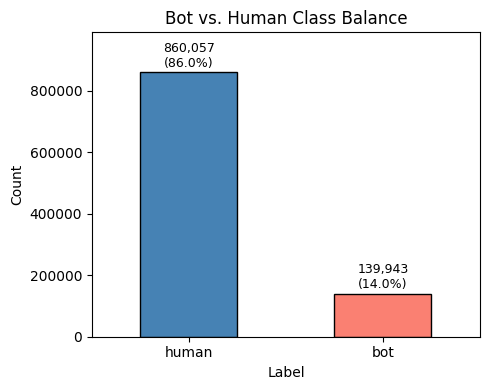

In [20]:
# Overall class balance
class_counts = labels["label"].value_counts()
class_pct    = labels["label"].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts.to_string())
print("\nClass Percentages:")
print(class_pct.round(2).to_string())

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind="bar", ax=ax, color=["steelblue", "salmon"], edgecolor="black")
ax.set_title("Bot vs. Human Class Balance")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_xticklabels(class_counts.index, rotation=0)

# Dynamic offset — 2% of the tallest bar instead of a hardcoded 1000
offset = class_counts.max() * 0.02
for i, v in enumerate(class_counts):
    ax.text(i, v + offset, f"{v:,}\n({class_pct.iloc[i]:.1f}%)", ha="center", fontsize=9)

# Give the y-axis extra headroom for the labels
ax.set_ylim(0, class_counts.max() * 1.15)

plt.tight_layout()
plt.show()

# Balance across splits (once split.csv arrives)
# split_label = splits.merge(labels, on="id")
# print("\nClass balance per split:")
# print(split_label.groupby("split")["label"].value_counts(normalize=True).unstack().round(3))

## User Profiles

NameError: name 'users_labeled' is not defined

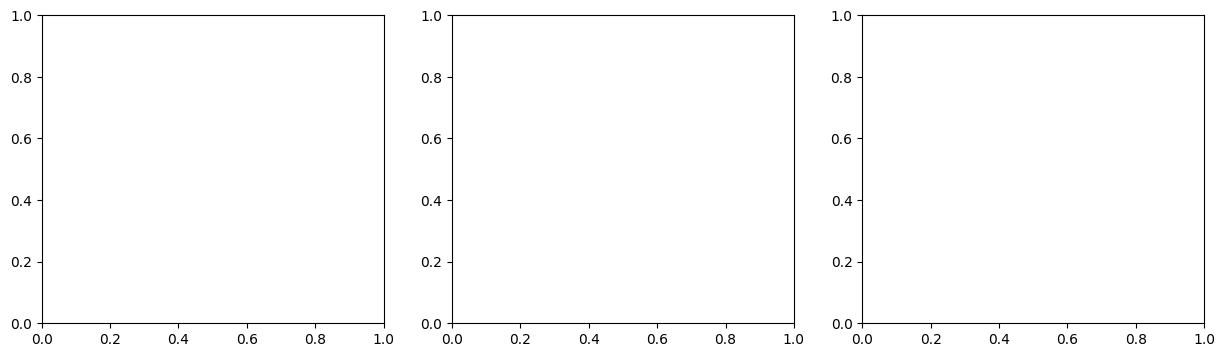

In [19]:
# --- Uncomment when user.json arrives ---
# users_labeled = users.merge(labels, on="id")

# Follower & following distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
    ["followers_count", "friends_count", "statuses_count"],
    ["Followers", "Following", "Tweet Count"]):
    for label, grp in users_labeled.groupby("label"):
        grp[col].clip(upper=grp[col].quantile(0.99)).plot(
            kind="hist", bins=50, alpha=0.6, ax=ax, label=label
        )
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle("User Count Distributions (clipped at 99th percentile)", y=1.02)
plt.tight_layout()
plt.show()

# Follower/following ratio
users_labeled["ff_ratio"] = users_labeled["followers_count"] / (
    users_labeled["friends_count"] + 1  # +1 avoids division by zero
)
print("Follower/Following Ratio by label:")
print(users_labeled.groupby("label")["ff_ratio"].describe().round(3))

# Account age (days since creation)
users_labeled["created_at"] = pd.to_datetime(users_labeled["created_at"])
users_labeled["account_age_days"] = (
    pd.Timestamp.now(tz="UTC") - users_labeled["created_at"]
).dt.days

fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in users_labeled.groupby("label"):
    grp["account_age_days"].plot(kind="hist", bins=50, alpha=0.6, ax=ax, label=label)
ax.set_title("Account Age Distribution")
ax.set_xlabel("Days since account creation")
ax.legend()
plt.tight_layout()
plt.show()

# Profile completeness
users_labeled["has_bio"]      = users_labeled["description"].notna() & (users_labeled["description"] != "")
users_labeled["has_location"] = users_labeled["location"].notna() & (users_labeled["location"] != "")
users_labeled["has_pic"]      = ~users_labeled["profile_image_url"].str.contains("default", na=True)

completeness_cols = ["has_bio", "has_location", "has_pic", "verified"]
completeness = users_labeled.groupby("label")[completeness_cols].mean().round(3) * 100
print("\nProfile Completeness (% of accounts):")
print(completeness.to_string())

## Tweet Behavior

In [ ]:
# --- Uncomment when tweet.json arrives ---
# tweets_labeled = tweets.merge(labels, on="author_id")  # or whichever join key Twibot-22 uses

# Posting frequency: tweets per user per day
tweet_counts = tweets_labeled.groupby(["author_id", "label"]).size().reset_index(name="tweet_count")
tweet_counts = tweet_counts.merge(users_labeled[["id", "account_age_days"]], left_on="author_id", right_on="id")
tweet_counts["tweets_per_day"] = tweet_counts["tweet_count"] / (tweet_counts["account_age_days"] + 1)

fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in tweet_counts.groupby("label"):
    grp["tweets_per_day"].clip(upper=grp["tweets_per_day"].quantile(0.99)).plot(
        kind="hist", bins=50, alpha=0.6, ax=ax, label=label
    )
ax.set_title("Tweet Frequency (per day, clipped at 99th pct)")
ax.legend()
plt.tight_layout()
plt.show()

# Retweet ratio per user
tweets_labeled["is_retweet"] = tweets_labeled["text"].str.startswith("RT @")
retweet_ratio = tweets_labeled.groupby(["author_id", "label"])["is_retweet"].mean().reset_index()
retweet_ratio.columns = ["author_id", "label", "retweet_ratio"]
print("Retweet Ratio by label:")
print(retweet_ratio.groupby("label")["retweet_ratio"].describe().round(3))

# Hashtag, mention, URL usage rates per tweet
tweets_labeled["hashtag_count"] = tweets_labeled["text"].str.count(r"#\w+")
tweets_labeled["mention_count"] = tweets_labeled["text"].str.count(r"@\w+")
tweets_labeled["url_count"]     = tweets_labeled["text"].str.count(r"http\S+")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
    ["hashtag_count", "mention_count", "url_count"],
    ["Hashtags per Tweet", "Mentions per Tweet", "URLs per Tweet"]):
    tweets_labeled.groupby("label")[col].mean().plot(kind="bar", ax=ax, color=["steelblue","salmon"], edgecolor="black")
    ax.set_title(f"Avg {title}")
    ax.set_xticklabels(["bot", "human"], rotation=0)

plt.suptitle("Tweet Content Feature Averages by Label", y=1.02)
plt.tight_layout()
plt.show()

## Network Structure

In [ ]:
# --- Uncomment when edge.csv arrives ---
# Build directed graph from follower/following edges
# follow_edges = edges[edges["relation"].isin(["followers", "following"])]
# G = nx.from_pandas_edgelist(
#     follow_edges, source="source_id", target="target_id", create_using=nx.DiGraph()
# )

# In-degree (followers) and out-degree (following) per node
# degree_df = pd.DataFrame({
#     "id":         list(G.nodes()),
#     "in_degree":  [d for _, d in G.in_degree()],
#     "out_degree": [d for _, d in G.out_degree()],
# }).merge(labels, on="id")

# Degree distributions by label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ["in_degree", "out_degree"], ["In-Degree (Followers)", "Out-Degree (Following)"]):
    for label, grp in degree_df.groupby("label"):
        grp[col].clip(upper=grp[col].quantile(0.99)).plot(
            kind="hist", bins=50, alpha=0.6, ax=ax, label=label
        )
    ax.set_title(f"Graph {title} Distribution")
    ax.legend()
plt.tight_layout()
plt.show()

# Are bots more isolated? Check % of nodes with degree 0
isolation = degree_df.groupby("label").apply(
    lambda g: (g["in_degree"] == 0).mean()
).rename("pct_isolated").round(3) * 100
print("\n% of accounts with zero followers (in-degree 0) by label:")
print(isolation.to_string())

# Clustering coefficient (undirected version — computationally expensive on large graphs, sample if needed)
# G_undirected = G.to_undirected()
# sample_nodes = list(G_undirected.nodes())[:5000]  # sample for speed
# clustering = nx.clustering(G_undirected, nodes=sample_nodes)
# clustering_df = pd.DataFrame(clustering.items(), columns=["id", "clustering_coef"]).merge(labels, on="id")
# print("\nClustering Coefficient by label:")
# print(clustering_df.groupby("label")["clustering_coef"].describe().round(3))

## Bot vs Human

In [21]:
# Summary statistics table comparing bots and humans across all numeric features
numeric_cols = [
    "followers_count", "friends_count", "statuses_count",
    "ff_ratio", "account_age_days",
    "has_bio", "has_location", "has_pic", "verified"
]

comparison = users_labeled.groupby("label")[numeric_cols].mean().T.round(3)
comparison["diff"] = (comparison["bot"] - comparison["human"]).round(3)
comparison["ratio"] = (comparison["bot"] / (comparison["human"] + 1e-9)).round(3)
print("Bot vs. Human — Mean Feature Comparison:")
display(comparison)

# Side-by-side boxplots for the most informative continuous features
continuous = ["followers_count", "friends_count", "ff_ratio", "account_age_days", "statuses_count"]

fig, axes = plt.subplots(1, len(continuous), figsize=(18, 5))
for ax, col in zip(axes, continuous):
    data = [
        users_labeled[users_labeled["label"] == "bot"][col].clip(
            upper=users_labeled[col].quantile(0.99)
        ),
        users_labeled[users_labeled["label"] == "human"][col].clip(
            upper=users_labeled[col].quantile(0.99)
        )
    ]
    ax.boxplot(data, labels=["bot", "human"], patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
    ax.set_title(col)
    ax.set_xlabel("Label")

plt.suptitle("Feature Distributions: Bot vs. Human (clipped at 99th pct)", y=1.02)
plt.tight_layout()
plt.show()

# Side-by-side bar chart for binary/rate features
binary_cols = ["has_bio", "has_location", "has_pic", "verified",
               "retweet_ratio", "hashtag_count", "mention_count", "url_count"]

# Pull tweet-level averages per user for the tweet features
tweet_user_avg = tweets_labeled.groupby(["author_id", "label"])[
    ["retweet_ratio", "hashtag_count", "mention_count", "url_count"]
].mean().reset_index()

combined = users_labeled[["id", "label"] + ["has_bio", "has_location", "has_pic", "verified"]].merge(
    tweet_user_avg, left_on=["id", "label"], right_on=["author_id", "label"], how="left"
)

rate_summary = combined.groupby("label")[binary_cols].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
rate_summary.T.plot(kind="bar", ax=ax, color=["steelblue", "salmon"], edgecolor="black")
ax.set_title("Bot vs. Human — Feature Rates (%)")
ax.set_ylabel("% of accounts / avg per tweet")
ax.set_xticklabels(rate_summary.columns, rotation=30, ha="right")
ax.legend(title="Label")
plt.tight_layout()
plt.show()

NameError: name 'users_labeled' is not defined

## Outliers

In [ ]:
# Flag statistically extreme values using IQR method
def flag_outliers(df, col, label_col="label"):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR  # 3x IQR = extreme outliers only
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n[{col}] {len(outliers):,} outliers ({len(outliers)/len(df)*100:.2f}%)")
    if len(outliers) > 0:
        print(outliers.groupby(label_col)[col].describe().round(2))
    return outliers

outlier_cols = ["followers_count", "friends_count", "statuses_count",
                "ff_ratio", "account_age_days", "tweets_per_day"]

print("=== Outlier Report ===")
outlier_dfs = {}
for col in outlier_cols:
    df_to_check = users_labeled if col in users_labeled.columns else tweet_counts
    outlier_dfs[col] = flag_outliers(df_to_check, col)

# Specific suspicious patterns worth flagging manually
print("\n=== Suspicious Pattern Checks ===")

# Accounts following huge numbers of people (follow-spam behavior)
follow_spam = users_labeled[users_labeled["friends_count"] > 5000]
print(f"\nAccounts following >5k people: {len(follow_spam):,}")
print(follow_spam["label"].value_counts())

# Accounts with zero tweets ever
no_tweets = users_labeled[users_labeled["statuses_count"] == 0]
print(f"\nAccounts with 0 tweets: {len(no_tweets):,}")
print(no_tweets["label"].value_counts())

# Accounts with impossibly high posting rates (>100 tweets/day)
if "tweets_per_day" in tweet_counts.columns:
    firehose = tweet_counts[tweet_counts["tweets_per_day"] > 100]
    print(f"\nAccounts tweeting >100x/day: {len(firehose):,}")
    print(firehose["label"].value_counts())

# Very new accounts (less than 30 days old)
new_accounts = users_labeled[users_labeled["account_age_days"] < 30]
print(f"\nAccounts under 30 days old: {len(new_accounts):,}")
print(new_accounts["label"].value_counts())

# Summary: how many total outlier accounts are there?
all_outlier_ids = set()
for col, df in outlier_dfs.items():
    id_col = "id" if "id" in df.columns else "author_id"
    all_outlier_ids.update(df[id_col].tolist())

print(f"\nTotal unique accounts flagged as outliers across all features: {len(all_outlier_ids):,}")
print(f"As % of dataset: {len(all_outlier_ids)/len(users_labeled)*100:.2f}%")